In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from ml.preprocess import (
    load_detect_dataset,
    load_class_dataset,
    scale_data,
    create_sequences,
    get_dataset_stats,
    SENSOR_COLS,
)
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from ml.isolation_forest import train_isolation_forest, get_anomaly_scores, save_model as save_if
from ml.lstm_model import train_lstm, get_reconstruction_errors, set_threshold, load_model
from ml.hybrid import hybrid_predict, classify_severity
from ml.explainability import (
    explain_with_shap,
    plot_shap_summary,
    explain_single_anomaly,
    get_top_contributing_sensors,
)
import numpy as np
from sklearn.model_selection import train_test_split


In [3]:
# Preprocessing detect_dataset

X, y = load_detect_dataset("../data/raw/detect_dataset.csv")
get_dataset_stats(X, y)

feature_names = SENSOR_COLS   # ["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]
X_scaled, scaler = scale_data(X)
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=10)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

   detect_dataset loaded: 12001 rows
   Normal: 6505 | Fault: 5496
   Fault rate: 45.8%

 Dataset Statistics:
              Ia         Ib         Ic         Va         Vb         Vc
count  12001.000  12001.000  12001.000  12001.000  12001.000  12001.000
mean       6.709    -26.558     22.353      0.011     -0.015      0.005
std      377.158    357.459    302.053      0.346      0.358      0.349
min     -883.542   -900.527   -883.358     -0.621     -0.660     -0.613
25%      -64.349    -51.422    -54.562     -0.238     -0.314     -0.279
50%       -3.240      4.711     -0.399      0.002     -0.007      0.008
75%       53.823     69.638     45.275      0.285      0.249      0.290
max      885.739    889.869    901.274      0.610      0.628      0.608

Class balance — Normal: 6505 | Fault: 5496


In [4]:
TIMESTEPS = 10
X_train_flat, X_test_flat, y_train_flat, y_test_flat = train_test_split(
    X_scaled[TIMESTEPS:], y.iloc[TIMESTEPS:].values,
    test_size=0.2,
    random_state=42,
    stratify=y.iloc[TIMESTEPS:].values
)

In [5]:
normal_train_mask = y_train_flat == 0
if_model = train_isolation_forest(X_train_flat[normal_train_mask])
if_scores_test, if_labels_test = get_anomaly_scores(if_model, X_test_flat)
save_if(if_model, path="../models/isolation_forest.pkl")

print(f"IF flags {if_labels_test.sum()} / {len(if_labels_test)} test samples as anomalous")

  Isolation Forest saved → ../models/isolation_forest.pkl
IF flags 1278 / 2399 test samples as anomalous


In [6]:
normal_seq_train_mask = y_train_seq == 0
X_normal_train = X_train_seq[normal_seq_train_mask]
lstm_model, train_losses = train_lstm(X_normal_train, epochs=40)

Training on: cpu
Epoch   0 | Train Loss: 0.23150 | Val Loss: 0.16907
Epoch   5 | Train Loss: 0.07595 | Val Loss: 0.02890
Epoch  10 | Train Loss: 0.01665 | Val Loss: 0.00950
Epoch  15 | Train Loss: 0.01275 | Val Loss: 0.01059
Epoch  20 | Train Loss: 0.01019 | Val Loss: 0.00685
Epoch  25 | Train Loss: 0.00952 | Val Loss: 0.00933
Epoch  30 | Train Loss: 0.00916 | Val Loss: 0.00727
Epoch  35 | Train Loss: 0.00860 | Val Loss: 0.00538


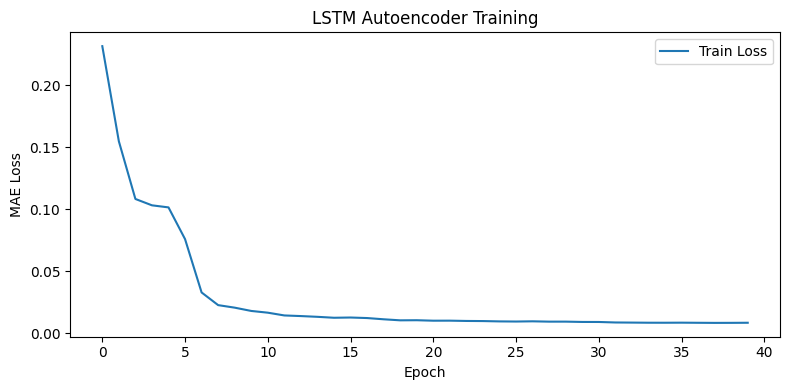

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch"); plt.ylabel("MAE Loss")
plt.title("LSTM Autoencoder Training")
plt.legend(); plt.tight_layout()
plt.savefig("../models/training_curve.png", dpi=150)


In [8]:
lstm_errors_train = get_reconstruction_errors(lstm_model, X_train_seq)
normal_train_errors = lstm_errors_train[y_train_seq == 0]
threshold = set_threshold(normal_train_errors, percentile=95)
...

 Anomaly threshold set at: 0.00885


Ellipsis

In [ ]:
# Hybrid predict on TEST set only 
combined_labels, confidence_scores = hybrid_predict(
    if_labels_test,
    lstm_errors_test,
    threshold
)

In [ ]:
print("\n Running SHAP explanations...")
shap_values = explain_with_shap(if_model, X_scaled, feature_names)
plot_shap_summary(shap_values, X_scaled, feature_names)

# Explain the first detected anomaly
anomaly_indices = np.where(combined_labels == 1)[0]
if len(anomaly_indices) > 0:
    sample = anomaly_indices[0]
    explain_single_anomaly(shap_values, X_scaled, sample, feature_names)
    reasons = get_top_contributing_sensors(shap_values, sample, feature_names)

    print(f"\n Anomaly #{sample} — Severity: {classify_severity(confidence_scores[sample])}")
    print("Root cause sensors:")
    for r in reasons:
        print(f"  → {r['sensor']}: {r['direction']} (impact: {r['impact']})")



 Running SHAP explanations...
 SHAP summary saved → ../models/shap_summary.png
 Explanation saved → ../models/explanation_0.png

 Anomaly #0 — Severity:  CRITICAL
Root cause sensors:
  → Ic: ↓ below normal (impact: -0.7493)
  → Ia: ↓ below normal (impact: -0.4698)
  → Vc: ↓ below normal (impact: -0.4681)


In [ ]:
X_cls, y_cls_binary, y_cls_type = load_class_dataset("../data/raw/classData.csv")
X_cls_scaled, _ = scale_data(X_cls, scaler=scaler)  # reuse same scaler!

print("\n Fault type distribution:")
print(y_cls_type.value_counts())

   classData ed: 7861 rows
   Fault types found:
No Fault                2365
Phase AB + Ground       1134
Three Phase + Ground    1133
Phase A + Ground        1129
Phase ABC Fault         1096
Phase BC Fault          1004

 Fault type distribution:
No Fault                2365
Phase AB + Ground       1134
Three Phase + Ground    1133
Phase A + Ground        1129
Phase ABC Fault         1096
Phase BC Fault          1004
Name: count, dtype: int64


In [ ]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")
print(" Scaler saved")

with open("../models/threshold.txt", "w") as f:
    f.write(str(threshold))
print(f" Threshold saved: {threshold:.5f}")

 Scaler saved
 Threshold saved: 0.01143


In [ ]:
import joblib
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from ml.preprocess import load_detect_dataset, scale_data, create_sequences
from ml.isolation_forest import get_anomaly_scores
from ml.lstm_model import get_reconstruction_errors
from ml.lstm_model import LSTMAutoencoder 

print("Loading data and recreating test split...")
X, y = load_detect_dataset("../data/raw/detect_dataset.csv")

scaler = joblib.load("../models/scaler.pkl")
X_scaled, _ = scale_data(X, scaler=scaler)

TIMESTEPS = 10
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=TIMESTEPS)

_, X_test_seq, _, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

_, X_test_flat, _, y_test_flat = train_tsest_split(
    X_scaled[TIMESTEPS:], y.iloc[TIMESTEPS:].values,
    test_size=0.2, random_state=42, stratify=y.iloc[TIMESTEPS:].values
)

print("Loading saved models...")
if_model = joblib.load("../models/isolation_forest.pkl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMAutoencoder(n_features=X_test_seq.shape[2]).to(device)
lstm_model.load_state_dict(torch.load("../models/lstm_best.pt", map_location=device, weights_only=True))
lstm_model.eval() 

with open("../models/threshold.txt", "r") as f:
    threshold = float(f.read().strip())

print("Running test data through models...")
if_scores_test, if_labels_test = get_anomaly_scores(if_model, X_test_flat)
lstm_errors_test = get_reconstruction_errors(lstm_model, X_test_seq)

combined_labels, confidence_scores = hybrid_predict(if_labels_test, lstm_errors_test, threshold)

# Filter out LOW severity / Noise (Keep only > 25% confidence)
actionable_labels = (confidence_scores > 0.25).astype(int)

print("\n" + "="*50)
print("CLASSIFICATION REPORT (Actionable Alerts > 25%)")
print("="*50)
print(classification_report(y_test_seq, actionable_labels, target_names=["Normal", "Fault"]))

try:
    auc = roc_auc_score(y_test_seq, confidence_scores)
    print(f"ROC-AUC Score: {auc:.4f}")
except Exception as e:
    pass

cm = confusion_matrix(y_test_seq, actionable_labels)
print(f"\nConfusion Matrix:")
print(f"  True Normal  predicted Normal: {cm[0][0]}")
print(f"  True Normal  predicted Fault:  {cm[0][1]}  ← False Alarms ")
print(f"  True Fault   predicted Normal: {cm[1][0]}  ← Missed Faults")
print(f"  True Fault   predicted Fault:  {cm[1][1]}" )

Loading data and recreating test split...
   detect_dataset loaded: 12001 rows
   Normal: 6505 | Fault: 5496
   Fault rate: 45.8%
Loading saved models...
Running test data through models...

CLASSIFICATION REPORT (Actionable Alerts > 25%)
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1299
       Fault       0.98      1.00      0.99      1100

    accuracy                           0.99      2399
   macro avg       0.99      0.99      0.99      2399
weighted avg       0.99      0.99      0.99      2399

ROC-AUC Score: 0.9986

Confusion Matrix:
  True Normal  predicted Normal: 1274
  True Normal  predicted Fault:  25  ← False Alarms (Should be very low/0)
  True Fault   predicted Normal: 2  ← Missed Faults
  True Fault   predicted Fault:  1098  ← Correctly Caught Faults
